In [27]:
import nltk 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df=pd.read_csv(r"D:\__Projects\LangFlow-Classifier\Data\Arabic\ar_reviews_100k.tsv",sep="\t")

In [29]:
df

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...
...,...,...
99994,Negative,معرفش ليه كنت عاوزة أكملها وهي مش عاجباني من ا...
99995,Negative,لا يستحق ان يكون في بوكنق لانه سيئ . لا شي. لا...
99996,Negative,كتاب ضعيف جدا ولم استمتع به. فى كل قصه سرد لحا...
99997,Negative,مملة جدا. محمد حسن علوان فنان بالكلمات، والوصف...


In [30]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [31]:
df.duplicated().sum()

0

<Axes: xlabel='label', ylabel='Count'>

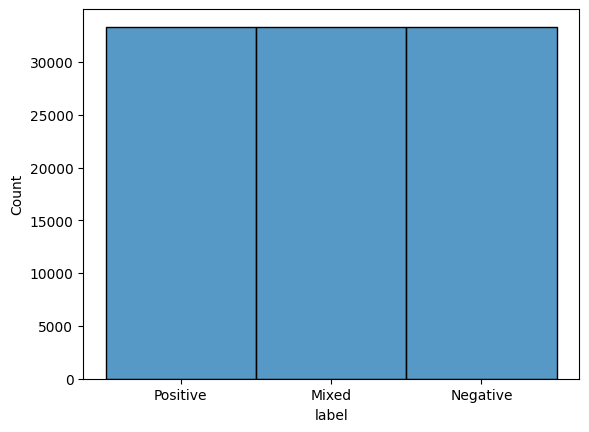

In [32]:
sns.histplot(df["label"])

In [33]:
df=df[df["label"]!="Mixed"]

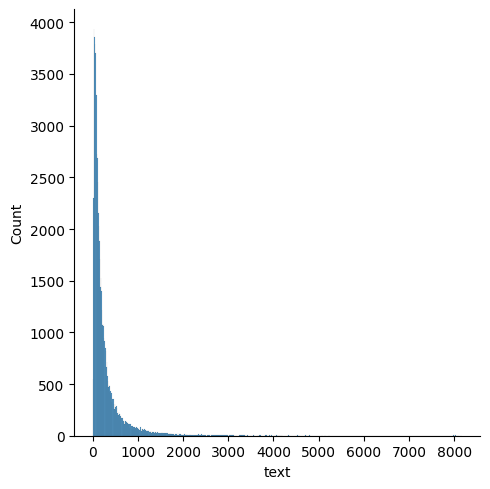

In [34]:
sns.displot(df["text"].str.len())


<Axes: ylabel='text'>

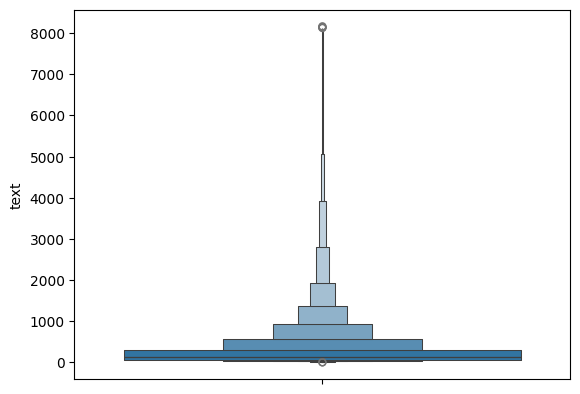

In [35]:
sns.boxenplot(df["text"].str.len())

In [36]:
print(df["label"].value_counts())
print("*"*50)
print(df["text"].str.len().describe())

label
Positive    33333
Negative    33333
Name: count, dtype: int64
**************************************************
count    66666.000000
mean       295.122656
std        520.303868
min          1.000000
25%         67.000000
50%        141.000000
75%        305.000000
max       8163.000000
Name: text, dtype: float64


In [37]:
df.loc[df["text"].str.len()<4]

,label,text
5115,Positive,مد
25193,Positive,أ
25799,Positive,عشق
70882,Negative,بلح
71094,Negative,فقع
73725,Negative,يع.
73819,Negative,هلك
75677,Negative,وحش
82686,Negative,سىء
89345,Negative,أمل


In [38]:
df=df.loc[df["text"].str.len()>2].copy()

In [39]:
df

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...
...,...,...
99994,Negative,معرفش ليه كنت عاوزة أكملها وهي مش عاجباني من ا...
99995,Negative,لا يستحق ان يكون في بوكنق لانه سيئ . لا شي. لا...
99996,Negative,كتاب ضعيف جدا ولم استمتع به. فى كل قصه سرد لحا...
99997,Negative,مملة جدا. محمد حسن علوان فنان بالكلمات، والوصف...


In [40]:
df["text"].str.len().max()

8163

(66020, 2)


<Axes: ylabel='text'>

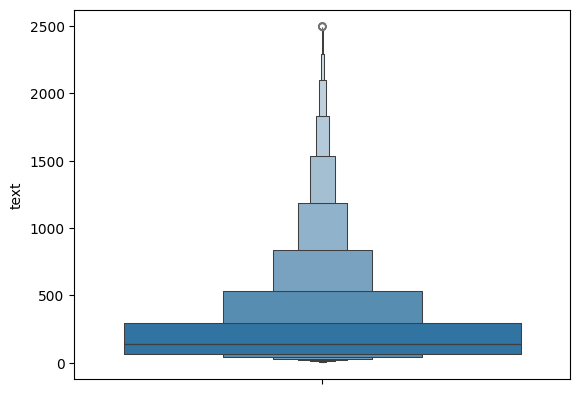

In [41]:
b=df.loc[df["text"].str.len()<2500]
print(b.shape)
sns.boxenplot(b["text"].str.len())


In [42]:
df=df.loc[df["text"].str.len()<2500].copy()

In [43]:
df

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...
...,...,...
99994,Negative,معرفش ليه كنت عاوزة أكملها وهي مش عاجباني من ا...
99995,Negative,لا يستحق ان يكون في بوكنق لانه سيئ . لا شي. لا...
99996,Negative,كتاب ضعيف جدا ولم استمتع به. فى كل قصه سرد لحا...
99997,Negative,مملة جدا. محمد حسن علوان فنان بالكلمات، والوصف...


In [44]:
print(nltk.corpus.stopwords.words("arabic"))

['إذ', 'إذا', 'إذما', 'إذن', 'أف', 'أقل', 'أكثر', 'ألا', 'إلا', 'التي', 'الذي', 'الذين', 'اللاتي', 'اللائي', 'اللتان', 'اللتيا', 'اللتين', 'اللذان', 'اللذين', 'اللواتي', 'إلى', 'إليك', 'إليكم', 'إليكما', 'إليكن', 'أم', 'أما', 'أما', 'إما', 'أن', 'إن', 'إنا', 'أنا', 'أنت', 'أنتم', 'أنتما', 'أنتن', 'إنما', 'إنه', 'أنى', 'أنى', 'آه', 'آها', 'أو', 'أولاء', 'أولئك', 'أوه', 'آي', 'أي', 'أيها', 'إي', 'أين', 'أين', 'أينما', 'إيه', 'بخ', 'بس', 'بعد', 'بعض', 'بك', 'بكم', 'بكم', 'بكما', 'بكن', 'بل', 'بلى', 'بما', 'بماذا', 'بمن', 'بنا', 'به', 'بها', 'بهم', 'بهما', 'بهن', 'بي', 'بين', 'بيد', 'تلك', 'تلكم', 'تلكما', 'ته', 'تي', 'تين', 'تينك', 'ثم', 'ثمة', 'حاشا', 'حبذا', 'حتى', 'حيث', 'حيثما', 'حين', 'خلا', 'دون', 'ذا', 'ذات', 'ذاك', 'ذان', 'ذانك', 'ذلك', 'ذلكم', 'ذلكما', 'ذلكن', 'ذه', 'ذو', 'ذوا', 'ذواتا', 'ذواتي', 'ذي', 'ذين', 'ذينك', 'ريث', 'سوف', 'سوى', 'شتان', 'عدا', 'عسى', 'عل', 'على', 'عليك', 'عليه', 'عما', 'عن', 'عند', 'غير', 'فإذا', 'فإن', 'فلا', 'فمن', 'في', 'فيم', 'فيما', 'فيه', 'فيها', '

In [45]:
import re
stop=nltk.corpus.stopwords.words("arabic")
def clean_text(text):
    text =re.sub(r'[^\w\s]', '', text) 
    text =re.sub("[إأآا]", "ا", text)
    text =re.sub("ى", "ي", text)
    words=text.split()
    words=[word for word in words if word not in stop]
    return " ".join(words)
   
df["text"]= df["text"].apply(clean_text)

In [46]:
def commom_word_per_label(df):
    for l in df["label"].unique():
        print(f"Label: {l}")
        common_words = df[df["label"]==l]["text"].str.split(expand=True).stack().value_counts().head(5)
        print(common_words)
        print("-" * 50)
commom_word_per_label(df)

Label: Positive
ان        18282
علي       14799
جدا       11074
الي        8142
الكتاب     6714
Name: count, dtype: int64
--------------------------------------------------
Label: Negative
ان         19476
علي        15801
جدا        12701
الرواية     8279
الكتاب      8215
Name: count, dtype: int64
--------------------------------------------------


In [47]:
#from wordcloud import WordCloud
#import arabic_reshaper
#from bidi.algorithm import get_display

#text = " ".join(df["text"])
#reshaped_text=arabic_reshaper.reshape(text)
#bidi_text=get_display(reshaped_text)

#wordcloud = WordCloud(width=800, height=400, background_color='white',font_path="arial.ttf").generate(bidi_text)
#plt.figure(figsize=(10,5))
#plt.imshow(wordcloud)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=500)
tfidf=tfidf.fit_transform(df["text"])

In [49]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
x=tfidf.toarray()
y=df["label"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
clf = GaussianNB()
clf.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [50]:
y_perd=clf.predict(x_test)
from sklearn.metrics import classification_report
print(classification_report(y_test,y_perd))

              precision    recall  f1-score   support

    Negative       0.76      0.76      0.76      6601
    Positive       0.76      0.77      0.76      6603

    accuracy                           0.76     13204
   macro avg       0.76      0.76      0.76     13204
weighted avg       0.76      0.76      0.76     13204

